<font size =8> Barnacle Detection by Training a Model
<font size =4>

In this experiment, I will tune a large pre-trained model. YOLO11 model is known for having exceptional object detection and counting abilities. By training it on a dataset of just Barnacles, I optimize its capabilities for the specific task of counting barnacles. I obtained the datatset of Barnacles from [Roboflow Universe](https://universe.roboflow.com/), world's largest collection of open source computer vision datasets and APIs.

In [40]:
from ultralytics import YOLO 
import matplotlib.pyplot as plt
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import fiftyone as fo 
from fiftyone.core.labels import Detections
import fiftyone.core.plots as fop
import fiftyone.brain as fob
import numpy as np
from PIL import Image
from helpers import extract_patches_from_coords, compute_patch_coordinates

In [26]:
import ipywidgets

<font size =5>Training and initializing the model 

<font size =4> The YOLO model was trained using a Barnacle Detection dataset for 50 epochs on Google Collab. The best weight  were downloaded and stored in the best.pt file in this directory. The YOLO model uses this set of weights for the inference section. If interested on the specifics of the training, you can check out the YOLO11.ipynb notebook, or the Training_Results directory.


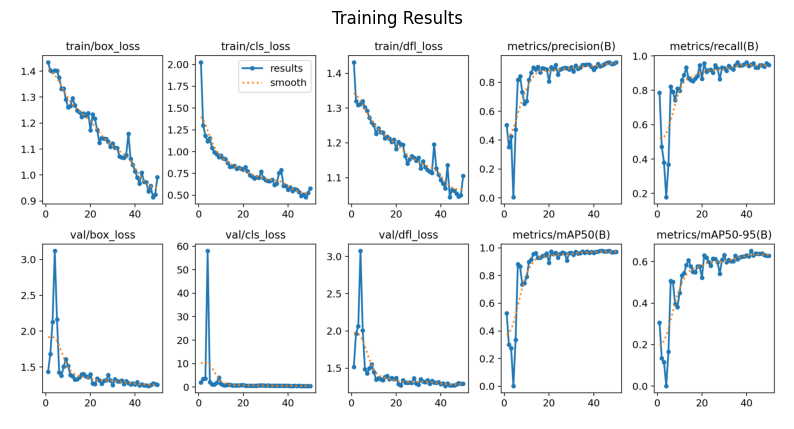

In [27]:
img = np.asarray(Image.open("Training_Results/YOLOv8/results.png"))
plt.figure(figsize=(10, 10))
plt.title("Training Results")
plt.axis("off")
plt.imshow(img)
plt.show()


<font size = 6>Initializing model 

In [89]:

model = AutoDetectionModel.from_pretrained(
        model_type = "ultralytics", 
        model_path = 'Training_Results/YOLO11/best.pt', 
        confidence_threshold=0.3, 
        device ="cpu")
    

def sahi_inference(image_filepath): 
    
    result = get_sliced_prediction(
        'images/sample_image.png',
        model, slice_height=256,
        slice_width=256,
        postprocess_match_metric="IOU",
        postprocess_match_threshold=0.2,
        overlap_height_ratio=0.2,
        postprocess_class_agnostic = True,
        overlap_width_ratio=0.2,
        )
    return result

# object_count = len(result[0].boxes)
# print(f" The number of barnacles is: {object_count}")


<font size =5> Preprocessing data by cropping it into smaller patches for training 

In [90]:
# #Creating patches for image1 and mask 1
# img1 = Image.open("images/image1.png").convert("RGB")
# mask1 = Image.open("masks/mask1.png").convert("L")  # Usually grayscale for masks
# assert img1.size == mask1.size
# coords_1 = compute_patch_coordinates(img1.size, patch_size=(256, 256), overlap_percentage=0.3)
# extract_patches_from_coords(img1, coords_1, output_dir="image_patches", prefix="image1")
# extract_patches_from_coords(mask1, coords_1, output_dir="mask_patches", prefix="mask1")


# #Creating patches for image2 and mask 2
# img2 = Image.open("images/image2.png").convert("RGB")
# mask2 = Image.open("masks/mask2.png").convert("L") 
# assert img2.size == mask2.size
# coords_2 = compute_patch_coordinates(img1.size, patch_size=(256, 256), overlap_percentage=0.3)
# extract_patches_from_coords(img2, coords_2, output_dir="image_patches", prefix="image2")
# extract_patches_from_coords(mask2, coords_2, output_dir="mask_patches", prefix="mask2")

<font size = 5> Creating custom dataset using fiftyone using the patched images. 

In [91]:
DATASET_NAME = "barnacle_dataset"
if fo.dataset_exists(DATASET_NAME):
    print(f"Deleting existing dataset: '{DATASET_NAME}'")
    fo.delete_dataset(DATASET_NAME)
    print(f"Dataset '{DATASET_NAME}' deleted successfully.")
else:
    print(f"Dataset '{DATASET_NAME}' does not exist (or was already deleted).")

Deleting existing dataset: 'barnacle_dataset'
Dataset 'barnacle_dataset' deleted successfully.


In [92]:

patched_dataset = fo.Dataset.from_images_dir(
    "image_patches",
    name="barnacle_dataset",
    persistent=False
)
# Add ground truth to this patched_dataset (similar to what you did for the full images)


# ... (logic to load mask patches and convert to fo.Detections) ...

 100% |█████████████████| 124/124 [59.1ms elapsed, 0s remaining, 2.1K samples/s]   


07/27/2025 10:01:45 - INFO - eta.core.utils -    100% |█████████████████| 124/124 [59.1ms elapsed, 0s remaining, 2.1K samples/s]   


In [94]:
import os 
MASK_DIR = "mask_patches"
IMAGE_DIR = "image_patches"
GROUND_TRUTH_FIELD = "ground_truth"
import cv2 

if GROUND_TRUTH_FIELD not in patched_dataset.get_field_schema():
    print(f"Adding ground truth masks to the '{GROUND_TRUTH_FIELD}' field...")
    
    filename_mapping = {
    os.path.basename(img): os.path.basename(mask)
    for img, mask in zip(sorted(os.listdir(IMAGE_DIR)), sorted(os.listdir(MASK_DIR)))
    if mask.endswith((".png", ".jpg", ".jpeg"))
}


    for sample in patched_dataset:   #Prepare masks for each image in the dataset
        img_filename = os.path.basename(sample.filepath)
        mask_filename = filename_mapping.get(img_filename) # handles cases where an image might not have a mask
        mask_path = os.path.join(MASK_DIR, mask_filename)

        if not os.path.exists(mask_path):
            print(f"Warning: Mask not found at {mask_path} for {img_filename}. Skipping ground truth for this sample.")
            continue

        # Use cv2.IMREAD_GRAYSCALE to ensure it's loaded as a single channel
        gt_mask_image = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        
        if gt_mask_image is None:
            print(f"Error: Could not load mask image from {mask_path}. Skipping ground truth.")
            continue

        # Binarizing
        _, binary_mask = cv2.threshold(gt_mask_image, 1, 255, cv2.THRESH_BINARY)

        # Connected component analysis
        num_labels, labels_img, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, 8, cv2.CV_32S)

        gt_detections = []

        for i in range(1, num_labels):
            # Create a boolean mask for the current instance
            instance_mask = (labels_img == i) 

            y_coords, x_coords = np.where(instance_mask)
            
            # Skip mask if empty 
            if y_coords.size == 0:
                continue

            x_min, x_max = x_coords.min(), x_coords.max()
            y_min, y_max = y_coords.min(), y_coords.max()

            img_height, img_width = gt_mask_image.shape[:2]
            
            bbox_width = max(1, x_max - x_min + 1)
            bbox_height = max(1, y_max - y_min + 1)

            rel_bounding_box = [
                x_min / img_width,
                y_min / img_height,
                bbox_width / img_width,
                bbox_height / img_height
            ]

            cropped_mask = instance_mask[y_min:y_max+1, x_min:x_max+1]

            gt_detections.append(
                fo.Detection(
                    label="barnacle",
                    bounding_box=rel_bounding_box,
                    mask=cropped_mask.astype(bool)  
                )
            )
        sample[GROUND_TRUTH_FIELD] = fo.Detections(detections=gt_detections)
        sample.save()

    print(f"Ground truth masks added to the '{GROUND_TRUTH_FIELD}' field for all samples.")
else:
    print(f"Field '{GROUND_TRUTH_FIELD}' already exists. Skipping ground truth addition.")

print(patched_dataset)
#Sanity Check 
sample = patched_dataset.first()
has_gt = sample.ground_truth is not None and len(sample.ground_truth.detections) > 0
print(f"Sample 1 has ground truth: {has_gt}")
print("-----------------------------------------------------------------------------------")

Field 'ground_truth' already exists. Skipping ground truth addition.
Name:        barnacle_dataset
Media type:  image
Num samples: 124
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
Sample 1 has ground truth: True
-----------------------------------------------------------------------------------


In [95]:
# --- Setup 1b: The Patched Images Dataset (for K-Fold training/validation) ---
# ... (code to load images into patched_dataset) ...
# ... (code to add ground truth masks to patched_dataset) ...

# <--- PLACE THESE DEBUG PRINTS HERE, AFTER YOUR GROUND TRUTH LOADING LOOP ---
print(f"\n--- DEBUGGING EXPORT ISSUE FOR PATCHED_DATASET ---")
print(f"Total samples in patched_dataset: {len(patched_dataset)}")
print(f"Does patched_dataset have the field '{GROUND_TRUTH_FIELD}'? {GROUND_TRUTH_FIELD in patched_dataset.get_field_schema()}")

sample_count_with_labels = 0
label_names_found = set()
for i, sample in enumerate(patched_dataset):
    if GROUND_TRUTH_FIELD in sample and sample[GROUND_TRUTH_FIELD].detections is not None:
        if len(sample[GROUND_TRUTH_FIELD].detections) > 0:
            sample_count_with_labels += 1
            for det in sample[GROUND_TRUTH_FIELD].detections:
                label_names_found.add(det.label)
        
    if i < 3: # Check first 3 samples in detail
        print(f"\nSample {i}: {os.path.basename(sample.filepath)}")
        if GROUND_TRUTH_FIELD in sample:
            current_labels = sample[GROUND_TRUTH_FIELD].detections
            print(f"  Number of detections in '{GROUND_TRUTH_FIELD}': {len(current_labels) if current_labels else 0}")
            if current_labels:
                for det_idx, det in enumerate(current_labels[:3]):
                    print(f"    Det {det_idx}: Label='{det.label}', BBox={det.bounding_box[:4]}, Mask={det.mask is not None}")
        else:
            print(f"  Field '{GROUND_TRUTH_FIELD}' is missing for this sample.")

print(f"\nTotal samples with at least one detection in '{GROUND_TRUTH_FIELD}': {sample_count_with_labels}")
print(f"All unique labels found in '{GROUND_TRUTH_FIELD}': {label_names_found}")
print(f"--- End Debugging Export Issue ---\n")
# --- END DEBUG PRINTS ---


--- DEBUGGING EXPORT ISSUE FOR PATCHED_DATASET ---
Total samples in patched_dataset: 124
Does patched_dataset have the field 'ground_truth'? True

Sample 0: image1_patch_0000.png
  Number of detections in 'ground_truth': 50
    Det 0: Label='barnacle', BBox=[0.93359375, 0.2265625, 0.06640625, 0.140625], Mask=True
    Det 1: Label='barnacle', BBox=[0.48046875, 0.27734375, 0.09375, 0.08203125], Mask=True
    Det 2: Label='barnacle', BBox=[0.15625, 0.2890625, 0.0703125, 0.12890625], Mask=True

Sample 1: image1_patch_0001.png
  Number of detections in 'ground_truth': 59
    Det 0: Label='barnacle', BBox=[0.71484375, 0.19140625, 0.12109375, 0.12890625], Mask=True
    Det 1: Label='barnacle', BBox=[0.234375, 0.2265625, 0.09375, 0.140625], Mask=True
    Det 2: Label='barnacle', BBox=[0.453125, 0.23046875, 0.078125, 0.08984375], Mask=True

Sample 2: image1_patch_0002.png
  Number of detections in 'ground_truth': 78
    Det 0: Label='barnacle', BBox=[0.78515625, 0.18359375, 0.11328125, 0.09765

In [101]:
import fiftyone.utils.yolo as fou
import fiftyone.types as fot

patched_dataset.export(
    export_dir="COCO_dataset",
    dataset_type=fot.COCODetectionDataset,
    label_field="ground_truth",
    export_media=True,    
)

 100% |█████████████████| 124/124 [18.8s elapsed, 0s remaining, 16.4 samples/s]      


07/27/2025 10:38:17 - INFO - eta.core.utils -    100% |█████████████████| 124/124 [18.8s elapsed, 0s remaining, 16.4 samples/s]      


In [102]:
from ultralytics.data.converter import convert_coco


convert_coco("COCO_dataset/",save_dir= "yolo_dataset",  use_segments=True, use_keypoints=False, cls91to80=False)



Annotations C:\Users\arses\Desktop\Barnacles\Trained_model\COCO_dataset\labels.json: 100%|██████████| 124/124 [00:00<00:00, 233.41it/s]

COCO data converted successfully.
Results saved to C:\Users\arses\Desktop\Barnacles\Trained_model\yolo_dataset


In [ ]:

# Randomly split the dataset into train and validation
patched_dataset.clear_view("train") 
patched_dataset.clear_view("validation")

patched_dataset.take(round(len(patched_dataset) * 0.8)).tag_samples("train") # 80% train
patched_dataset.exclude(F("tags").contains("train")).tag_samples("validation") # Remaining 20% validation

print(f"Dataset split into {len(patched_dataset.match_tags('train'))} train and {len(patched_dataset.match_tags('validation'))} validation samples.")

In [ ]:
# Export the training split
patched_dataset.match_tags("train").export(
    export_dir="path/to/yolo_dataset/train",
    dataset_type=fo.types.YOLOv8Dataset, # Or YOLOv5Dataset, which uses same format
    label_field=GROUND_TRUTH_FIELD, #The field where your ground truth masks are
    classes=["barnacle"], # Your class names
    # For segmentation, ensure your ground truth labels have the `mask` attribute correctly populated.
)
print("Train split exported to YOLOv8 format.")

# Export the validation split
patched_dataset.match_tags("validation").export(
    export_dir="path/to/yolo_dataset/val",
    dataset_type=fo.types.YOLOv8Dataset,
    label_field=GROUND_TRUTH_FIELD,
    classes=["barnacle"],
)
print("Validation split exported to YOLOv8 format.")

# Manually create a dataset.yaml in your "path/to/yolo_dataset" root:
# data.yaml content (example):
# path: /path/to/yolo_dataset # Absolute path to this folder
# train: images/train
# val: images/val
# nc: 1
# names: ['barnacle']

<font size = 6> Optional: App-like GUI for datatset visualization

<font size=4> Fiftyone allows you to visualize data using their app-like GUI feature, which I thought was really cool and one of the reasons why I worked with Fiftyone. However, after trying to run it, I ran into a lot of errors and glitches. So, I haven't run it in this notebook but you are open to try if you want!

In [ ]:
dataset = fo.load_dataset("barnacle_v8")
session = fo.launch_app(dataset)
predictions_view = dataset.take(2)
session.view = predictions_view
session.view = None
session.show()